# Simulacion: Sistema multiagente de coordinacion de horarios

Este notebook corre la simulacion definida en `horarios_multiagente.py`:
evalua utilidades, selecciona el horario optimo (con y sin penalizacion por
varianza), muestra el efecto de un evento inesperado (replanificacion), y
genera una animacion en video (`.mp4`) mostrando como se va construyendo el
horario final bloque a bloque y como crece la utilidad de cada companero.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath("."))

import statistics
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import imageio_ffmpeg
from IPython.display import Video

plt.rcParams['animation.ffmpeg_path'] = imageio_ffmpeg.get_ffmpeg_exe()

import horarios_multiagente as hm

DIAS = hm.DIAS
print("Modulo cargado:", hm.__file__)

Modulo cargado: C:\Users\rbeta\horarios_multiagentes\horarios_multiagente.py


## 1. Construir el caso de ejemplo (agentes y bloques candidatos)

In [2]:
agentes, bloques = hm.construir_caso_ejemplo()
sistema = hm.SistemaMultiagente(agentes, bloques, T_max=7.0, lam=2.5)

for a in agentes:
    print(a.id, a.nombre, "duro:", a.ocupado_duro, "blando:", a.ocupado_blando)
print()
for b in bloques:
    print(b)

A1 Ana duro: [(0, 8, 9)] blando: [(1, 10, 11)]
A2 Bruno duro: [(1, 15, 17)] blando: []
A3 Carla duro: [] blando: [(0, 13, 14), (2, 9, 10)]
A4 Diego duro: [(2, 8, 10)] blando: []

B1:Diseno de API (tarea) (Lunes 10.0-12.0h)
B2:Revision de API (reunion) (Lunes 13.0-14.0h)
B3:Sync semanal (Martes 9.0-10.0h)
B4:Pair programming (Martes 11.0-13.0h)
B5:Demo a cliente (Miercoles 11.0-12.0h)
B6:Retro de sprint (Miercoles 15.0-16.0h)
B7:1:1 mentoria (Jueves 9.0-9.5h)
B8:Planning siguiente sprint (Jueves 14.0-15.5h)


## 2. Utilidad de cada bloque para cada agente participante

In [3]:
utilidades_bloques = sistema.evaluar_utilidades()
for b_id, utils in utilidades_bloques.items():
    legibles = ", ".join(f"{sistema.agentes[a].nombre}={u:.2f}" for a, u in utils.items())
    print(f"{b_id} ({sistema.bloques[b_id].nombre}): {legibles}")

B1 (Diseno de API (tarea)): Ana=6.60, Carla=6.60
B2 (Revision de API (reunion)): Ana=7.80, Bruno=7.80, Carla=7.30
B3 (Sync semanal): Ana=5.80, Bruno=5.80, Carla=5.80, Diego=5.80
B4 (Pair programming): Bruno=5.60, Diego=5.60
B5 (Demo a cliente): Ana=9.80, Bruno=9.80, Diego=9.80
B6 (Retro de sprint): Ana=4.80, Bruno=4.80, Carla=4.80, Diego=4.80
B7 (1:1 mentoria): Carla=4.90, Diego=4.90
B8 (Planning siguiente sprint): Ana=6.70, Bruno=6.70, Carla=6.70, Diego=6.70


## 3. Seleccion optima: con equidad (lambda>0) vs sin equidad (lambda=0)

In [4]:
seleccion_lam, J_lam, util_lam = sistema.seleccionar_optimo(lam=sistema.lam)
seleccion_sin_lam, J_sin_lam, util_sin_lam = sistema.seleccionar_optimo(lam=0.0)

def resumen(nombre, seleccion, J, utilidades):
    print(f"=== {nombre} ===")
    print(f"J = {J:.3f}")
    for b in sorted(seleccion, key=lambda x: (x.dia, x.inicio)):
        print(" ", b)
    for a_id, u in utilidades.items():
        print(f"  {sistema.agentes[a_id].nombre}: {u:.2f}")
    var = statistics.pvariance(list(utilidades.values()))
    print(f"  Varianza: {var:.3f}\n")

resumen(f"lambda={sistema.lam} (con equidad)", seleccion_lam, J_lam, util_lam)
resumen("lambda=0 (sin equidad)", seleccion_sin_lam, J_sin_lam, util_sin_lam)

=== lambda=2.5 (con equidad) ===
J = 104.788
  B1:Diseno de API (tarea) (Lunes 10.0-12.0h)
  B3:Sync semanal (Martes 9.0-10.0h)
  B5:Demo a cliente (Miercoles 11.0-12.0h)
  B6:Retro de sprint (Miercoles 15.0-16.0h)
  B7:1:1 mentoria (Jueves 9.0-9.5h)
  B8:Planning siguiente sprint (Jueves 14.0-15.5h)
  Ana: 33.70
  Bruno: 27.10
  Carla: 28.80
  Diego: 32.00
  Varianza: 6.725

=== lambda=0 (sin equidad) ===
J = 125.300
  B1:Diseno de API (tarea) (Lunes 10.0-12.0h)
  B2:Revision de API (reunion) (Lunes 13.0-14.0h)
  B3:Sync semanal (Martes 9.0-10.0h)
  B5:Demo a cliente (Miercoles 11.0-12.0h)
  B7:1:1 mentoria (Jueves 9.0-9.5h)
  B8:Planning siguiente sprint (Jueves 14.0-15.5h)
  Ana: 36.70
  Bruno: 30.10
  Carla: 31.30
  Diego: 27.20
  Varianza: 11.852



## 4. Bonus: evento inesperado y replanificacion\n\nDiego (A4) queda ocupado el jueves 14:00-16:00h a mitad de la coordinacion; el sistema vuelve a resolver la seleccion optima respetando la nueva restriccion.

In [5]:
seleccion_repl, J_repl, util_repl = sistema.replanificar("A4", (3, 14, 16), lam=sistema.lam)
resumen("Replanificacion tras evento inesperado", seleccion_repl, J_repl, util_repl)

=== Replanificacion tras evento inesperado ===
J = 88.070
  B1:Diseno de API (tarea) (Lunes 10.0-12.0h)
  B2:Revision de API (reunion) (Lunes 13.0-14.0h)
  B3:Sync semanal (Martes 9.0-10.0h)
  B5:Demo a cliente (Miercoles 11.0-12.0h)
  B6:Retro de sprint (Miercoles 15.0-16.0h)
  B7:1:1 mentoria (Jueves 9.0-9.5h)
  Ana: 34.80
  Bruno: 28.20
  Carla: 29.40
  Diego: 25.30
  Varianza: 11.852



## 5. Q-Learning: aprendiendo la seleccion de bloques (Algoritmo 3)\n\nEn vez de enumerar por fuerza bruta los `2**n` subconjuntos de bloques, `QLearningPlanner` trata la seleccion como un MDP episodico: recorre los bloques en un orden fijo y en cada paso decide incluir o excluir el bloque actual (solo si mantiene la seleccion factible). La recompensa es 0 en cada paso intermedio y `J` (la utilidad social) solo al terminar el episodio, asi que el valor de una decision temprana depende del retorno futuro descontado -- la misma logica de la ecuacion de Bellman. Se entrena con politica epsilon-greedy (epsilon decae de 1.0 a 0.05) y se compara, como evidencia empirica, contra el optimo de fuerza bruta y contra una linea base aleatoria, promediando sobre varias semillas.

In [6]:
SEMILLAS = list(range(10))
N_EPISODIOS = 8000

curvas, curvas_td, J_finales = [], [], []
for s in SEMILLAS:
    planner = hm.QLearningPlanner(sistema, alpha=0.15, gamma=0.95, lam=sistema.lam, semilla=s)
    historial = planner.entrenar(n_episodios=N_EPISODIOS)
    curvas.append(historial)
    curvas_td.append(planner.historial_td_error)
    _, J_final, _ = planner.mejor_politica()
    J_finales.append(J_final)

curvas = np.array(curvas)  # (n_semillas, n_episodios)
curvas_td = np.array(curvas_td)
media = curvas.mean(axis=0)
desv = curvas.std(axis=0)

# Linea base: seleccion aleatoria de bloques respetando factibilidad
import random as _random

def episodio_aleatorio(sistema, orden, rng):
    seleccion = frozenset()
    for bloque_id in orden:
        candidato = seleccion | {bloque_id}
        bloques_cand = [sistema.bloques[i] for i in candidato]
        if sistema.es_factible(bloques_cand) and rng.random() < 0.5:
            seleccion = candidato
    J, _ = sistema.utilidad_social([sistema.bloques[i] for i in seleccion], lam=sistema.lam)
    return J

rng_base = _random.Random(123)
orden = list(sistema.bloques.keys())
J_aleatorio = [episodio_aleatorio(sistema, orden, rng_base) for _ in range(2000)]
media_aleatorio = np.mean(J_aleatorio)

print(f"Q-Learning, J final: media={np.mean(J_finales):.2f} +/- {np.std(J_finales):.2f} "
      f"sobre {len(SEMILLAS)} semillas")
print(f"Linea base aleatoria, J promedio: {media_aleatorio:.2f}")
print(f"Optimo por fuerza bruta (lambda={sistema.lam}): {J_lam:.2f}")

Q-Learning, J final: media=77.86 +/- 11.58 sobre 10 semillas
Linea base aleatoria, J promedio: 18.74
Optimo por fuerza bruta (lambda=2.5): 104.79


Grafico guardado en qlearning_convergencia.png


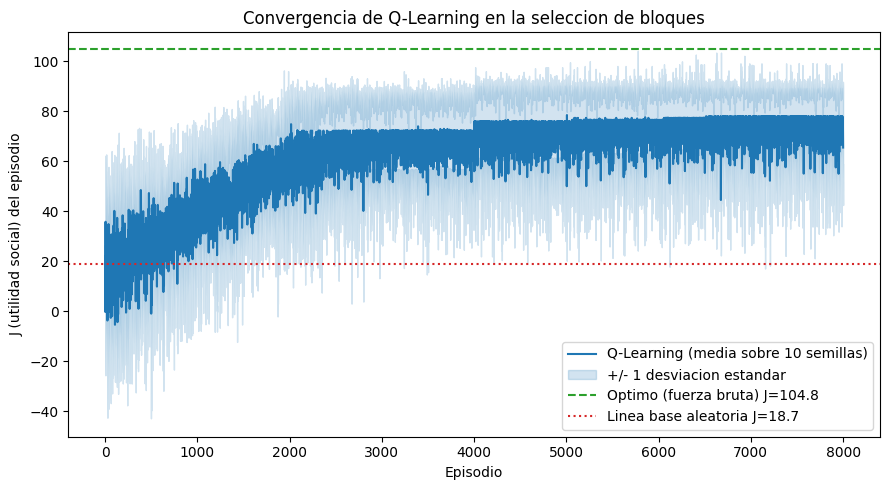

In [7]:
episodios = np.arange(1, N_EPISODIOS + 1)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(episodios, media, color="tab:blue", label="Q-Learning (media sobre 10 semillas)")
ax.fill_between(episodios, media - desv, media + desv, color="tab:blue", alpha=0.2,
                label="+/- 1 desviacion estandar")
ax.axhline(J_lam, color="tab:green", linestyle="--", label=f"Optimo (fuerza bruta) J={J_lam:.1f}")
ax.axhline(media_aleatorio, color="tab:red", linestyle=":", label=f"Linea base aleatoria J={media_aleatorio:.1f}")
ax.set_xlabel("Episodio")
ax.set_ylabel("J (utilidad social) del episodio")
ax.set_title("Convergencia de Q-Learning en la seleccion de bloques")
ax.legend()
fig.tight_layout()
fig.savefig("qlearning_convergencia.png", dpi=150)
print("Grafico guardado en qlearning_convergencia.png")
plt.show()

### 5.1 Horario segun la politica aprendida (ultima semilla) vs. el optimo\n\nSe corre la politica greedy aprendida (sin exploracion) y se compara su horario final contra la seleccion optima de fuerza bruta.

In [8]:
seleccion_ql, J_ql, util_ql = planner.mejor_politica()
resumen("Politica aprendida por Q-Learning (ultima semilla)", seleccion_ql, J_ql, util_ql)
resumen(f"Optimo por fuerza bruta (lambda={sistema.lam})", seleccion_lam, J_lam, util_lam)

=== Politica aprendida por Q-Learning (ultima semilla) ===
J = 88.070
  B1:Diseno de API (tarea) (Lunes 10.0-12.0h)
  B2:Revision de API (reunion) (Lunes 13.0-14.0h)
  B3:Sync semanal (Martes 9.0-10.0h)
  B5:Demo a cliente (Miercoles 11.0-12.0h)
  B6:Retro de sprint (Miercoles 15.0-16.0h)
  B7:1:1 mentoria (Jueves 9.0-9.5h)
  Ana: 34.80
  Bruno: 28.20
  Carla: 29.40
  Diego: 25.30
  Varianza: 11.852

=== Optimo por fuerza bruta (lambda=2.5) ===
J = 104.788
  B1:Diseno de API (tarea) (Lunes 10.0-12.0h)
  B3:Sync semanal (Martes 9.0-10.0h)
  B5:Demo a cliente (Miercoles 11.0-12.0h)
  B6:Retro de sprint (Miercoles 15.0-16.0h)
  B7:1:1 mentoria (Jueves 9.0-9.5h)
  B8:Planning siguiente sprint (Jueves 14.0-15.5h)
  Ana: 33.70
  Bruno: 27.10
  Carla: 28.80
  Diego: 32.00
  Varianza: 6.725



### 5.2 Panel de diagnostico del entrenamiento\n\nCuatro vistas complementarias del mismo entrenamiento: (a) como decae epsilon (exploracion -> explotacion), (b) el error TD promedio por episodio -- cuanto se "sorprende" el agente, que debe ir bajando si esta aprendiendo, (c) que tan variable es el resultado final entre las 10 semillas frente al optimo, y (d) un acercamiento al ultimo 20% de episodios para ver si la curva ya se estabilizo.

Grafico guardado en qlearning_panel_diagnostico.png


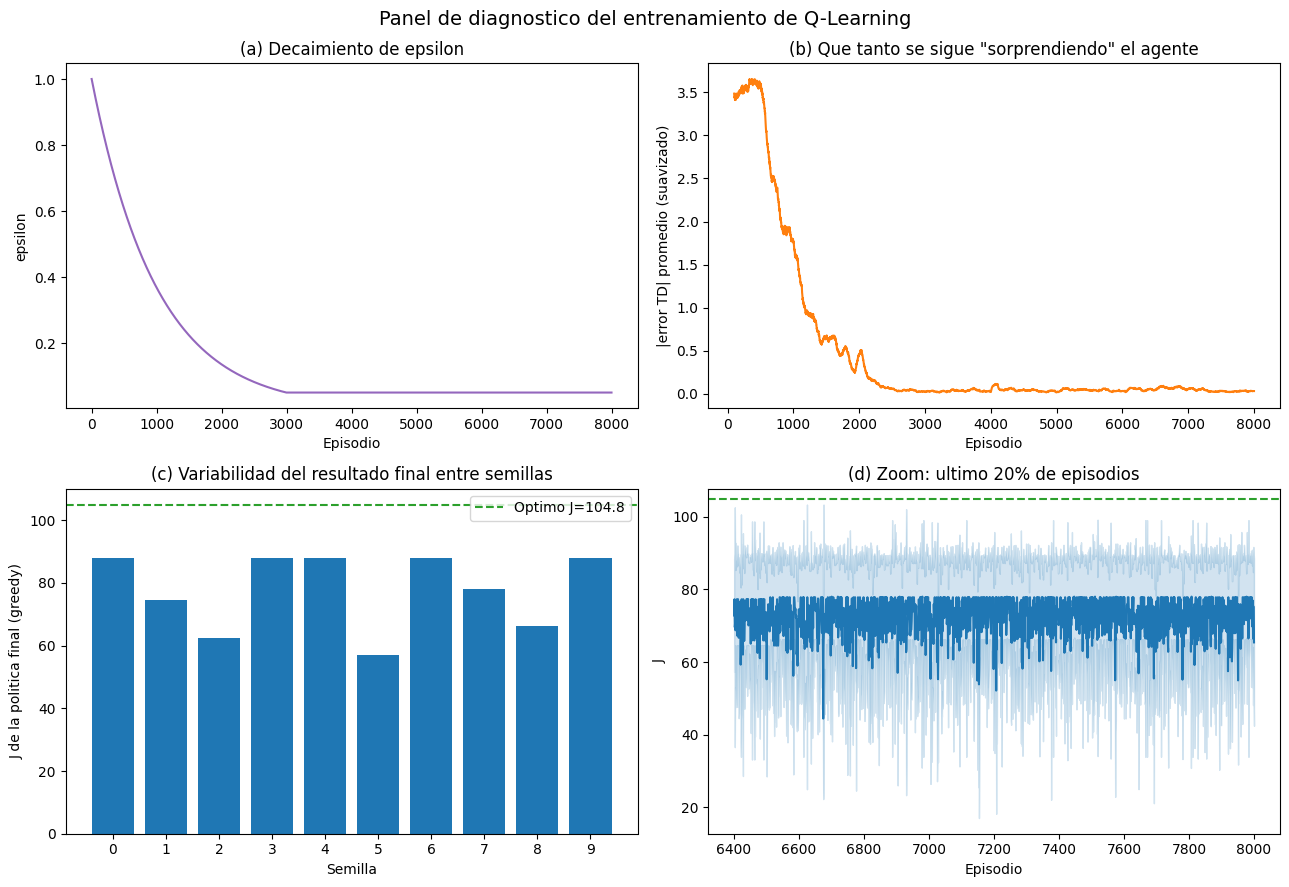

In [9]:
def suavizar(x, ventana=100):
    x = np.asarray(x, dtype=float)
    if len(x) < ventana:
        return x
    kernel = np.ones(ventana) / ventana
    return np.convolve(x, kernel, mode="valid")

fig, axes = plt.subplots(2, 2, figsize=(13, 9))

ax = axes[0, 0]
ax.plot(episodios, planner.historial_epsilon, color="tab:purple")
ax.set_xlabel("Episodio")
ax.set_ylabel("epsilon")
ax.set_title("(a) Decaimiento de epsilon")

ax = axes[0, 1]
td_medio = curvas_td.mean(axis=0)
td_suave = suavizar(td_medio, ventana=100)
ax.plot(np.arange(len(td_suave)) + 100, td_suave, color="tab:orange")
ax.set_xlabel("Episodio")
ax.set_ylabel("|error TD| promedio (suavizado)")
ax.set_title("(b) Que tanto se sigue \"sorprendiendo\" el agente")

ax = axes[1, 0]
ax.bar([str(s) for s in SEMILLAS], J_finales, color="tab:blue")
ax.axhline(J_lam, color="tab:green", linestyle="--", label=f"Optimo J={J_lam:.1f}")
ax.set_xlabel("Semilla")
ax.set_ylabel("J de la politica final (greedy)")
ax.set_title("(c) Variabilidad del resultado final entre semillas")
ax.legend()

ax = axes[1, 1]
desde = int(N_EPISODIOS * 0.8)
ax.plot(episodios[desde:], media[desde:], color="tab:blue")
ax.fill_between(episodios[desde:], (media - desv)[desde:], (media + desv)[desde:],
                color="tab:blue", alpha=0.2)
ax.axhline(J_lam, color="tab:green", linestyle="--")
ax.set_xlabel("Episodio")
ax.set_ylabel("J")
ax.set_title("(d) Zoom: ultimo 20% de episodios")

fig.suptitle("Panel de diagnostico del entrenamiento de Q-Learning", fontsize=14)
fig.tight_layout()
fig.savefig("qlearning_panel_diagnostico.png", dpi=150)
print("Grafico guardado en qlearning_panel_diagnostico.png")
plt.show()

### 5.3 Animacion del entrenamiento\n\nSe anima como se construye, episodio a episodio, la curva de convergencia (media +/- desviacion estandar sobre las 10 semillas) junto con el decaimiento de epsilon, para ver el aprendizaje "en movimiento" en vez de solo la foto final. Se guarda como `qlearning_entrenamiento.mp4`.

In [10]:
PASO_FRAME = 100  # cada cuantos episodios se agrega un frame nuevo
checkpoints = list(range(PASO_FRAME, N_EPISODIOS + 1, PASO_FRAME))
if checkpoints[-1] != N_EPISODIOS:
    checkpoints.append(N_EPISODIOS)

y_min = min(media_aleatorio, float(curvas.min())) - 5
y_max = J_lam + 10

fig, (ax_curva, ax_eps) = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Entrenamiento de Q-Learning en vivo")

def dibujar_frame(k):
    ax_curva.clear()
    ax_eps.clear()

    hasta = checkpoints[k]
    ep = episodios[:hasta]

    ax_curva.plot(ep, media[:hasta], color="tab:blue", label="Q-Learning (media 10 semillas)")
    ax_curva.fill_between(ep, (media - desv)[:hasta], (media + desv)[:hasta],
                           color="tab:blue", alpha=0.2, label="+/- 1 desv. estandar")
    ax_curva.axhline(J_lam, color="tab:green", linestyle="--", label=f"Optimo J={J_lam:.1f}")
    ax_curva.axhline(media_aleatorio, color="tab:red", linestyle=":", label=f"Aleatorio J={media_aleatorio:.1f}")
    ax_curva.set_xlim(0, N_EPISODIOS)
    ax_curva.set_ylim(y_min, y_max)
    ax_curva.set_xlabel("Episodio")
    ax_curva.set_ylabel("J (utilidad social)")
    ax_curva.set_title(f"Episodio {hasta}/{N_EPISODIOS}")
    ax_curva.legend(loc="lower right", fontsize=8)

    ax_eps.plot(ep, planner.historial_epsilon[:hasta], color="tab:purple")
    ax_eps.set_xlim(0, N_EPISODIOS)
    ax_eps.set_ylim(0, 1.05)
    ax_eps.set_xlabel("Episodio")
    ax_eps.set_ylabel("epsilon")
    ax_eps.set_title("Exploracion (epsilon) a lo largo del entrenamiento")

n_frames = len(checkpoints)
# se repiten los ultimos cuadros para apreciar el resultado final unos segundos
frames = list(range(n_frames)) + [n_frames - 1] * 10

ani = animation.FuncAnimation(fig, dibujar_frame, frames=frames, interval=120, repeat=False)

writer = animation.FFMpegWriter(fps=10, bitrate=1800)
salida_entrenamiento_mp4 = "qlearning_entrenamiento.mp4"
ani.save(salida_entrenamiento_mp4, writer=writer)
plt.close(fig)
print(f"Animacion guardada en {salida_entrenamiento_mp4}")

Animacion guardada en qlearning_entrenamiento.mp4


In [11]:
Video(salida_entrenamiento_mp4, embed=True, width=900)

## 6. Animacion del horario final construyendose bloque a bloque\n\nSe anima la seleccion optima (con equidad, antes del evento inesperado): en cada cuadro se agrega un bloque mas al horario semanal y se actualiza la utilidad acumulada de cada companero. Se guarda como `horario_simulacion.mp4`.

In [12]:
orden = sorted(seleccion_lam, key=lambda b: (b.dia, b.inicio))
colores = plt.cm.tab10.colors
color_por_bloque = {b.id: colores[i % len(colores)] for i, b in enumerate(orden)}
nombres_agentes = [sistema.agentes[a_id].nombre for a_id in sistema.agentes]
ids_agentes = list(sistema.agentes.keys())

fig, (ax_bar, ax_sched) = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Construccion del horario optimo (lambda={:.1f})".format(sistema.lam))

def dibujar_frame(k):
    ax_bar.clear()
    ax_sched.clear()

    parciales = orden[:k]
    util_parcial = sistema.utilidad_por_agente(parciales)
    valores = [util_parcial[a_id] for a_id in ids_agentes]

    ax_bar.bar(nombres_agentes, valores, color="tab:blue")
    ax_bar.set_ylim(0, max(util_lam.values()) * 1.15)
    ax_bar.set_ylabel("Utilidad acumulada U_i")
    ax_bar.set_title(f"Bloques asignados: {k}/{len(orden)}")

    for b in parciales:
        ax_sched.barh(y=DIAS[b.dia], width=b.duracion, left=b.inicio, height=0.5,
                       color=color_por_bloque[b.id], edgecolor="black")
        ax_sched.text(b.inicio + b.duracion / 2, DIAS[b.dia], b.id,
                       ha="center", va="center", fontsize=8)
    ax_sched.set_xlim(7, 18)
    ax_sched.set_yticks(range(len(DIAS)))
    ax_sched.set_yticklabels(DIAS)
    ax_sched.invert_yaxis()
    ax_sched.set_xlabel("Hora del dia")
    ax_sched.set_title("Horario semanal")

n_frames = len(orden) + 1
# se repiten los ultimos cuadros para poder apreciar el resultado final unos segundos
frames = list(range(n_frames)) + [n_frames - 1] * 8

ani = animation.FuncAnimation(fig, dibujar_frame, frames=frames, interval=600, repeat=False)

writer = animation.FFMpegWriter(fps=2, bitrate=1800)
salida_mp4 = "horario_simulacion.mp4"
ani.save(salida_mp4, writer=writer)
plt.close(fig)
print(f"Animacion guardada en {salida_mp4}")

Animacion guardada en horario_simulacion.mp4


In [13]:
Video(salida_mp4, embed=True, width=900)

## 7. Animacion del horario segun Q-Learning (maximo local) vs. el optimo\n\nEl video anterior anima el **optimo global** encontrado por fuerza bruta. Aqui se anima, de la misma forma, la **politica aprendida por Q-Learning** -- un maximo local: se queda corta frente al optimo, pero se puede ver en que difiere: que bloques omite o cambia, y como eso se refleja en la utilidad acumulada de cada companero. Se guarda como `horario_qlearning.mp4`.

In [14]:
orden_ql = sorted(seleccion_ql, key=lambda b: (b.dia, b.inicio))
color_por_bloque_ql = {b.id: colores[i % len(colores)] for i, b in enumerate(orden_ql)}
techo_util = max(max(util_lam.values()), max(util_ql.values())) * 1.15

fig, (ax_bar, ax_sched) = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle(f"Construccion del horario segun Q-Learning (J={J_ql:.1f}, optimo J={J_lam:.1f})")

def dibujar_frame(k):
    ax_bar.clear()
    ax_sched.clear()

    parciales = orden_ql[:k]
    util_parcial = sistema.utilidad_por_agente(parciales)
    valores = [util_parcial[a_id] for a_id in ids_agentes]

    ax_bar.bar(nombres_agentes, valores, color="tab:orange")
    ax_bar.set_ylim(0, techo_util)
    ax_bar.set_ylabel("Utilidad acumulada U_i")
    ax_bar.set_title(f"Bloques asignados: {k}/{len(orden_ql)}")

    for b in parciales:
        ax_sched.barh(y=DIAS[b.dia], width=b.duracion, left=b.inicio, height=0.5,
                       color=color_por_bloque_ql[b.id], edgecolor="black")
        ax_sched.text(b.inicio + b.duracion / 2, DIAS[b.dia], b.id,
                       ha="center", va="center", fontsize=8)
    ax_sched.set_xlim(7, 18)
    ax_sched.set_yticks(range(len(DIAS)))
    ax_sched.set_yticklabels(DIAS)
    ax_sched.invert_yaxis()
    ax_sched.set_xlabel("Hora del dia")
    ax_sched.set_title("Horario semanal (Q-Learning)")

n_frames = len(orden_ql) + 1
frames = list(range(n_frames)) + [n_frames - 1] * 8

ani = animation.FuncAnimation(fig, dibujar_frame, frames=frames, interval=600, repeat=False)

writer = animation.FFMpegWriter(fps=2, bitrate=1800)
salida_ql_mp4 = "horario_qlearning.mp4"
ani.save(salida_ql_mp4, writer=writer)
plt.close(fig)
print(f"Animacion guardada en {salida_ql_mp4}")

Animacion guardada en horario_qlearning.mp4


In [15]:
Video(salida_ql_mp4, embed=True, width=900)

### 7.1 Diferencia entre ambas soluciones\n\nQue bloques elige uno y no el otro.

In [11]:
ids_lam = {b.id for b in seleccion_lam}
ids_ql = {b.id for b in seleccion_ql}

print(f"Solo en el optimo (fuerza bruta):  {sorted(ids_lam - ids_ql)}")
print(f"Solo en Q-Learning:                {sorted(ids_ql - ids_lam)}")
print(f"En ambos:                          {sorted(ids_lam & ids_ql)}")
print(f"\nJ optimo = {J_lam:.2f}   J Q-Learning = {J_ql:.2f}   "
      f"brecha = {J_lam - J_ql:.2f} ({(J_lam - J_ql) / J_lam:.1%} por debajo del optimo)")

Solo en el optimo (fuerza bruta):  ['B8']
Solo en Q-Learning:                ['B2']
En ambos:                          ['B1', 'B3', 'B5', 'B6', 'B7']

J optimo = 104.79   J Q-Learning = 88.07   brecha = 16.72 (16.0% por debajo del optimo)
